In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import math

# Load dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Convert to categorical (ID3 works on categorical features)
X = pd.qcut(X.iloc[:,0], 3, labels=["low","medium","high"]).to_frame()

data = X.copy()
data['target'] = y

# Entropy function
def entropy(target):
    values, counts = np.unique(target, return_counts=True)
    entropy = 0
    for i in range(len(values)):
        p = counts[i]/sum(counts)
        entropy += -p * math.log2(p)
    return entropy

# Information Gain
def information_gain(data, feature, target="target"):
    total_entropy = entropy(data[target])
    values, counts = np.unique(data[feature], return_counts=True)
    weighted_entropy = 0
    for i in range(len(values)):
        subset = data[data[feature] == values[i]]
        weighted_entropy += (counts[i]/sum(counts)) * entropy(subset[target])
    return total_entropy - weighted_entropy

# Build simple tree (1-level for demo)
best_feature = information_gain(data, X.columns[0])

print("Information Gain:", best_feature)

Information Gain: 0.6469506438553063


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, y, test_size=0.3, random_state=42)

from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(criterion="entropy")
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9777777777777777
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  1 12]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.93      1.00      0.96        13
           2       1.00      0.92      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



In [3]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

clf = DecisionTreeClassifier(criterion="entropy")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9532163742690059
Confusion Matrix:
 [[ 57   6]
 [  2 106]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.93        63
           1       0.95      0.98      0.96       108

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171



In [4]:
import numpy as np
import pandas as pd
import math
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [5]:
# Load dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Convert to categorical (discretization)
for col in X.columns:
    X[col] = pd.qcut(X[col], 3, labels=["Low", "Medium", "High"])

data = X.copy()
data["target"] = y

In [6]:
def entropy(target_col):
    values, counts = np.unique(target_col, return_counts=True)
    entropy_value = 0
    print("\nClass Distribution:")
    
    for i in range(len(values)):
        p = counts[i] / sum(counts)
        print(f"Class {values[i]}: Count = {counts[i]}, Probability = {p:.4f}")
        entropy_value += -p * math.log2(p)
    
    print(f"Entropy = {entropy_value:.4f}")
    return entropy_value

In [7]:
def information_gain(data, feature, target="target"):
    print(f"\nCalculating Information Gain for Feature: {feature}")
    
    total_entropy = entropy(data[target])
    values, counts = np.unique(data[feature], return_counts=True)
    
    weighted_entropy = 0
    for i in range(len(values)):
        subset = data[data[feature] == values[i]]
        print(f"\nSubset for {feature} = {values[i]}")
        subset_entropy = entropy(subset[target])
        weight = counts[i] / sum(counts)
        weighted_entropy += weight * subset_entropy
    
    info_gain = total_entropy - weighted_entropy
    print(f"\nInformation Gain for {feature} = {info_gain:.4f}")
    return info_gain

In [8]:
def id3(data, features, target="target"):
    
    # If all target values same → return leaf
    if len(np.unique(data[target])) == 1:
        return np.unique(data[target])[0]
    
    # If no features left
    if len(features) == 0:
        return data[target].mode()[0]
    
    # Compute information gain for all features
    gains = [information_gain(data, feature, target) for feature in features]
    
    # Select best feature
    best_feature = features[np.argmax(gains)]
    print(f"\nBest Feature Chosen: {best_feature}\n")
    
    tree = {best_feature: {}}
    
    for value in np.unique(data[best_feature]):
        subset = data[data[best_feature] == value]
        subtree = id3(subset, [f for f in features if f != best_feature])
        tree[best_feature][value] = subtree
    
    return tree

In [9]:
features = list(X.columns)
tree = id3(data, features)
print("\nFinal Decision Tree:\n", tree)


Calculating Information Gain for Feature: sepal length (cm)

Class Distribution:
Class 0: Count = 50, Probability = 0.3333
Class 1: Count = 50, Probability = 0.3333
Class 2: Count = 50, Probability = 0.3333
Entropy = 1.5850

Subset for sepal length (cm) = High

Class Distribution:
Class 1: Count = 11, Probability = 0.2619
Class 2: Count = 31, Probability = 0.7381
Entropy = 0.8296

Subset for sepal length (cm) = Low

Class Distribution:
Class 0: Count = 45, Probability = 0.8654
Class 1: Count = 6, Probability = 0.1154
Class 2: Count = 1, Probability = 0.0192
Entropy = 0.6496

Subset for sepal length (cm) = Medium

Class Distribution:
Class 0: Count = 5, Probability = 0.0893
Class 1: Count = 33, Probability = 0.5893
Class 2: Count = 18, Probability = 0.3214
Entropy = 1.2871

Information Gain for sepal length (cm) = 0.6470

Calculating Information Gain for Feature: sepal width (cm)

Class Distribution:
Class 0: Count = 50, Probability = 0.3333
Class 1: Count = 50, Probability = 0.3333
Cl

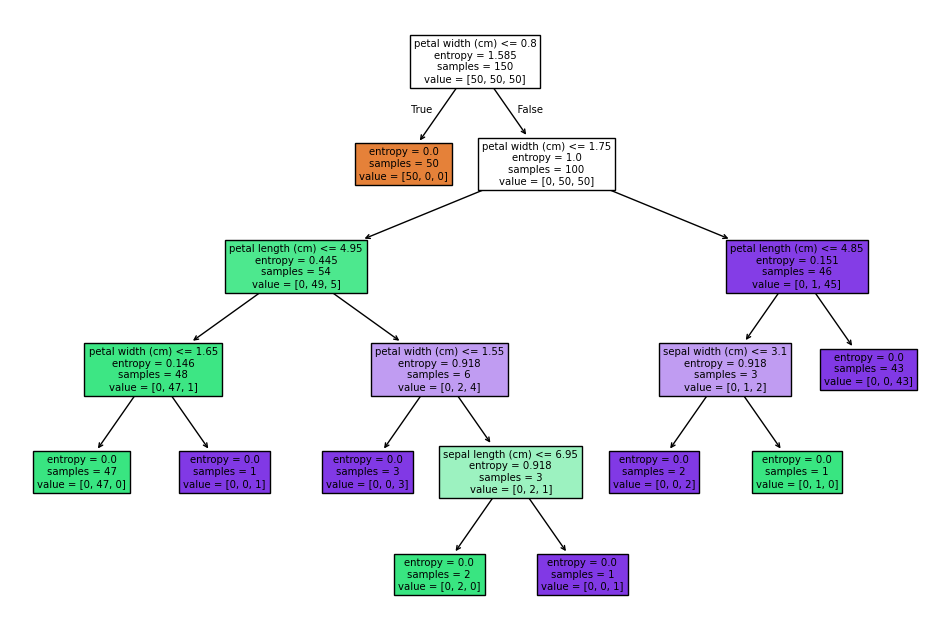

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

clf = DecisionTreeClassifier(criterion="entropy")
clf.fit(iris.data, iris.target)

plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names=iris.feature_names)
plt.show()

In [28]:
from sklearn.model_selection import train_test_split

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Discretize again
for col in X.columns:
    X[col] = pd.qcut(X[col], 3, labels=["Low","Medium","High"])

data_iris = X.copy()
data_iris["target"] = y

train_data, test_data = train_test_split(data_iris, test_size=0.3, random_state=42)

In [29]:
features = list(X.columns)

tree_iris = id3(train_data, features, target="target")


--- Calculating Gain for sepal length (cm) ---

Class Distribution:
0: 31 (0.295)
1: 37 (0.352)
2: 37 (0.352)
Entropy = 1.5802

Subset: sepal length (cm) = High

Class Distribution:
1: 7 (0.250)
2: 21 (0.750)
Entropy = 0.8113

Subset: sepal length (cm) = Low

Class Distribution:
0: 29 (0.806)
1: 6 (0.167)
2: 1 (0.028)
Entropy = 0.8257

Subset: sepal length (cm) = Medium

Class Distribution:
0: 2 (0.049)
1: 24 (0.585)
2: 15 (0.366)
Entropy = 1.1955

Information Gain(sepal length (cm)) = 0.6139

--- Calculating Gain for sepal width (cm) ---

Class Distribution:
0: 31 (0.295)
1: 37 (0.352)
2: 37 (0.352)
Entropy = 1.5802

Subset: sepal width (cm) = High

Class Distribution:
0: 20 (0.741)
2: 7 (0.259)
Entropy = 0.8256

Subset: sepal width (cm) = Low

Class Distribution:
0: 2 (0.047)
1: 26 (0.605)
2: 15 (0.349)
Entropy = 1.1748

Subset: sepal width (cm) = Medium

Class Distribution:
0: 9 (0.257)
1: 11 (0.314)
2: 15 (0.429)
Entropy = 1.5525

Information Gain(sepal width (cm)) = 0.3692

--- C

In [30]:
y_true = test_data["target"].values
y_pred = []

for _, row in test_data.iterrows():
    prediction = predict(tree_iris, row)
    y_pred.append(prediction)

In [31]:
print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))

Accuracy: 0.9777777777777777

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  1 12]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.93      1.00      0.96        13
           2       1.00      0.92      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



In [17]:
data = pd.DataFrame({
    "Outlook": ["Sunny","Sunny","Overcast","Rain","Rain","Rain",
                "Overcast","Sunny","Sunny","Rain","Sunny","Overcast",
                "Overcast","Rain"],
    
    "Temperature": ["Hot","Hot","Hot","Mild","Cool","Cool",
                    "Mild","Cool","Mild","Mild","Mild","Mild",
                    "Hot","Mild"],
    
    "Humidity": ["High","High","High","High","Normal","Normal",
                 "Normal","High","Normal","Normal","Normal","High",
                 "Normal","High"],
    
    "Windy": ["False","True","False","False","False","True",
              "True","False","False","False","True","True",
              "False","True"],
    
    "Play": ["No","No","Yes","Yes","Yes","No",
             "Yes","No","Yes","Yes","Yes","Yes",
             "Yes","No"]
})

print(data)

     Outlook Temperature Humidity  Windy Play
0      Sunny         Hot     High  False   No
1      Sunny         Hot     High   True   No
2   Overcast         Hot     High  False  Yes
3       Rain        Mild     High  False  Yes
4       Rain        Cool   Normal  False  Yes
5       Rain        Cool   Normal   True   No
6   Overcast        Mild   Normal   True  Yes
7      Sunny        Cool     High  False   No
8      Sunny        Mild   Normal  False  Yes
9       Rain        Mild   Normal  False  Yes
10     Sunny        Mild   Normal   True  Yes
11  Overcast        Mild     High   True  Yes
12  Overcast         Hot   Normal  False  Yes
13      Rain        Mild     High   True   No


In [18]:
def entropy(target_col):
    values, counts = np.unique(target_col, return_counts=True)
    entropy_value = 0
    
    print("\nClass Distribution:")
    for i in range(len(values)):
        p = counts[i] / sum(counts)
        print(f"{values[i]}: {counts[i]} ({p:.3f})")
        entropy_value += -p * math.log2(p)
    
    print(f"Entropy = {entropy_value:.4f}")
    return entropy_value

In [19]:
def information_gain(data, feature, target="Play"):
    
    print(f"\n--- Calculating Gain for {feature} ---")
    
    total_entropy = entropy(data[target])
    
    values, counts = np.unique(data[feature], return_counts=True)
    weighted_entropy = 0
    
    for i in range(len(values)):
        subset = data[data[feature] == values[i]]
        print(f"\nSubset: {feature} = {values[i]}")
        subset_entropy = entropy(subset[target])
        weight = counts[i] / sum(counts)
        weighted_entropy += weight * subset_entropy
    
    gain = total_entropy - weighted_entropy
    print(f"\nInformation Gain({feature}) = {gain:.4f}")
    
    return gain

In [20]:
def id3(data, features, target="Play"):
    
    # If all same class → return leaf
    if len(np.unique(data[target])) == 1:
        return np.unique(data[target])[0]
    
    # If no features left
    if len(features) == 0:
        return data[target].mode()[0]
    
    # Calculate gain for all features
    gains = [information_gain(data, feature, target) for feature in features]
    
    best_feature = features[np.argmax(gains)]
    print(f"\nBest Feature Selected: {best_feature}\n")
    
    tree = {best_feature: {}}
    
    for value in np.unique(data[best_feature]):
        subset = data[data[best_feature] == value]
        
        subtree = id3(
            subset,
            [f for f in features if f != best_feature],
            target
        )
        
        tree[best_feature][value] = subtree
    
    return tree

In [21]:
features = ["Outlook","Temperature","Humidity","Windy"]

tree = id3(data, features)

print("\nFinal Decision Tree:\n")
print(tree)


--- Calculating Gain for Outlook ---

Class Distribution:
No: 5 (0.357)
Yes: 9 (0.643)
Entropy = 0.9403

Subset: Outlook = Overcast

Class Distribution:
Yes: 4 (1.000)
Entropy = 0.0000

Subset: Outlook = Rain

Class Distribution:
No: 2 (0.400)
Yes: 3 (0.600)
Entropy = 0.9710

Subset: Outlook = Sunny

Class Distribution:
No: 3 (0.600)
Yes: 2 (0.400)
Entropy = 0.9710

Information Gain(Outlook) = 0.2467

--- Calculating Gain for Temperature ---

Class Distribution:
No: 5 (0.357)
Yes: 9 (0.643)
Entropy = 0.9403

Subset: Temperature = Cool

Class Distribution:
No: 2 (0.667)
Yes: 1 (0.333)
Entropy = 0.9183

Subset: Temperature = Hot

Class Distribution:
No: 2 (0.500)
Yes: 2 (0.500)
Entropy = 1.0000

Subset: Temperature = Mild

Class Distribution:
No: 1 (0.143)
Yes: 6 (0.857)
Entropy = 0.5917

Information Gain(Temperature) = 0.1620

--- Calculating Gain for Humidity ---

Class Distribution:
No: 5 (0.357)
Yes: 9 (0.643)
Entropy = 0.9403

Subset: Humidity = High

Class Distribution:
No: 4 (0.5

In [23]:
def print_tree(tree, indent=""):
    if isinstance(tree, dict):
        for key in tree:
            print(indent + key)
            for value in tree[key]:
                print(indent + " ├─ " + value)
                print_tree(tree[key][value], indent + " │   ")
    else:
        print(indent + " →", tree)

In [24]:
print_tree(tree)

Outlook
 ├─ Overcast
 │    → Yes
 ├─ Rain
 │   Windy
 │    ├─ False
 │    │    → Yes
 │    ├─ True
 │    │    → No
 ├─ Sunny
 │   Temperature
 │    ├─ Cool
 │    │    → No
 │    ├─ Hot
 │    │    → No
 │    ├─ Mild
 │    │    → Yes


In [25]:
def predict(tree, instance):
    
    if not isinstance(tree, dict):
        return tree
    
    root = next(iter(tree))
    value = instance[root]
    
    subtree = tree[root].get(value)
    
    if isinstance(subtree, dict):
        return predict(subtree, instance)
    else:
        return subtree

In [26]:
y_true = data["Play"].values

y_pred = []

for _, row in data.iterrows():
    prediction = predict(tree, row)
    y_pred.append(prediction)

In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[5 0]
 [0 9]]

Classification Report:
               precision    recall  f1-score   support

          No       1.00      1.00      1.00         5
         Yes       1.00      1.00      1.00         9

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14

